#### Individual-level anomaly analysis

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

In [3]:
daily_path = daily_data
external_path = external_data

In [4]:
war_date = pd.Timestamp("2022-02-24")

window_months = 30
start = war_date - pd.DateOffset(months=0)
end = war_date + pd.DateOffset(months=window_months)


In [5]:
attack_threshold = 50
top_n = 10

In [6]:
private_cols = ["msg_count", "audio_count"]
public_cols = ["post_count", "comment_count", "reaction_count"]

In [7]:
from functools import reduce

files_cols = [
    ('donor_daily_message_count.csv', 'donor_daily_message_count', 'msg_count'),
    ('donor_daily_audio.csv', 'donor_daily_audio_count', 'audio_count'),
    ('donor_daily_posts.csv', 'donor_daily_post_count', 'post_count'),
    ('donor_daily_comments.csv', 'donor_daily_comment_count', 'comment_count'),
    ('donor_daily_reactions.csv', 'donor_daily_reaction_count','reaction_count'),
]

dfs = []
for fname, src_col, dst_col in files_cols:
    tmp = pd.read_csv(daily_path / fname)
    tmp['date'] = pd.to_datetime(tmp['date'])
    tmp = tmp.rename(columns={src_col: dst_col})[['donation_id', 'date', dst_col]]
    dfs.append(tmp)

df = reduce(lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'), dfs)
df = df.fillna(0)
df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= start) & (df["date"] <= end)]

df["private"] = df[private_cols].sum(axis=1)
df["public"] = df[public_cols].sum(axis=1)

print(f"Donors: {df['donation_id'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Donors: 24
Date range: 2022-02-24 → 2024-08-24


#### Find top 10 high and top 10 low days per donor (raw data)

In [8]:
donor_high = {"private": {}, "public": {}}
donor_low  = {"private": {}, "public": {}}

for donor_id, grp in df.groupby("donation_id"):
    grp = grp.sort_values("date")
    for activity in ["private", "public"]:
        donor_high[activity][donor_id] = set(
            grp.nlargest(top_n, activity)["date"].dt.normalize().tolist()
        )
        active_days = grp[grp[activity] > 0]
        donor_low[activity][donor_id] = set(
            active_days.nsmallest(top_n, activity)["date"].dt.normalize().tolist()
        )

n_donors = df["donation_id"].nunique()


In [9]:
attacks = pd.read_csv(external_path / 'massive_attacks_by_category.csv', low_memory=False)
attacks["date"] = pd.to_datetime(attacks["date_start"]).dt.normalize()
attacks = attacks[(attacks["date"] >= start) & (attacks["date"] <= end)]
massive = attacks[attacks["Total"] >= attack_threshold].copy()
attack_dates = set(massive["date"].tolist())

print(f"Massive attack days (Total >= {attack_threshold}): {len(massive)}")


Massive attack days (Total >= 50): 33


#### Count how many donors shared each anomalous day

In [10]:
summary = {}

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

for activity in ["private", "public"]:
    for direction, donor_dict in [("high", donor_high[activity]), ("low", donor_low[activity])]:
        counter = Counter()
        for donor in donor_dict:
            for d in donor_dict[donor]:
                counter[d] += 1

        top_days = pd.DataFrame(counter.most_common(10), columns=["date", "n_donors"])
        top_days["pct_donors"] = (top_days["n_donors"] / n_donors * 100).round(1)
        top_days["is_attack"]  = top_days["date"].isin(attack_dates)
        top_days["attack_total"] = top_days["date"].map(
            lambda d: massive[massive["date"] == d]["Total"].values[0] if d in attack_dates else 0
        )
        summary[(activity, direction)] = top_days

        print(f"\n {activity} — {direction} anomaly (top 20 most shared days)")
        display(top_days)
        n_attack = top_days["is_attack"].sum()
        print(f"Days coinciding with massive attack: {n_attack}/20")



 private — high anomaly (top 20 most shared days)


,date,n_donors,pct_donors,is_attack,attack_total
0,2022-04-11,4,16.7,False,0
1,2023-08-21,3,12.5,False,0
2,2022-04-14,3,12.5,False,0
3,2022-04-13,3,12.5,False,0
4,2023-02-24,2,8.3,False,0
5,2024-07-19,2,8.3,False,0
6,2023-07-27,2,8.3,False,0
7,2022-09-02,2,8.3,False,0
8,2022-08-29,2,8.3,False,0
9,2022-03-28,2,8.3,False,0


Days coinciding with massive attack: 0/20

 private — low anomaly (top 20 most shared days)


,date,n_donors,pct_donors,is_attack,attack_total
0,2022-06-08,4,16.7,False,0
1,2022-06-12,4,16.7,False,0
2,2022-03-01,4,16.7,False,0
3,2022-03-08,4,16.7,False,0
4,2022-05-17,3,12.5,False,0
5,2022-03-02,3,12.5,False,0
6,2022-03-10,3,12.5,False,0
7,2022-05-15,3,12.5,False,0
8,2022-04-07,3,12.5,False,0
9,2022-07-26,3,12.5,False,0


Days coinciding with massive attack: 0/20

 public — high anomaly (top 20 most shared days)


,date,n_donors,pct_donors,is_attack,attack_total
0,2022-02-25,4,16.7,False,0
1,2022-11-14,3,12.5,False,0
2,2022-02-24,3,12.5,False,0
3,2024-02-11,3,12.5,False,0
4,2022-02-26,3,12.5,False,0
5,2024-03-28,2,8.3,False,0
6,2023-10-06,2,8.3,False,0
7,2024-01-04,2,8.3,False,0
8,2022-05-19,2,8.3,False,0
9,2023-04-30,2,8.3,False,0


Days coinciding with massive attack: 0/20

 public — low anomaly (top 20 most shared days)


,date,n_donors,pct_donors,is_attack,attack_total
0,2022-03-27,6,25.0,False,0
1,2022-03-22,6,25.0,False,0
2,2022-03-16,5,20.8,False,0
3,2022-03-01,5,20.8,False,0
4,2022-03-07,5,20.8,False,0
5,2022-04-11,5,20.8,False,0
6,2022-03-24,4,16.7,False,0
7,2022-03-19,4,16.7,False,0
8,2022-03-17,4,16.7,False,0
9,2022-04-08,4,16.7,False,0


Days coinciding with massive attack: 0/20


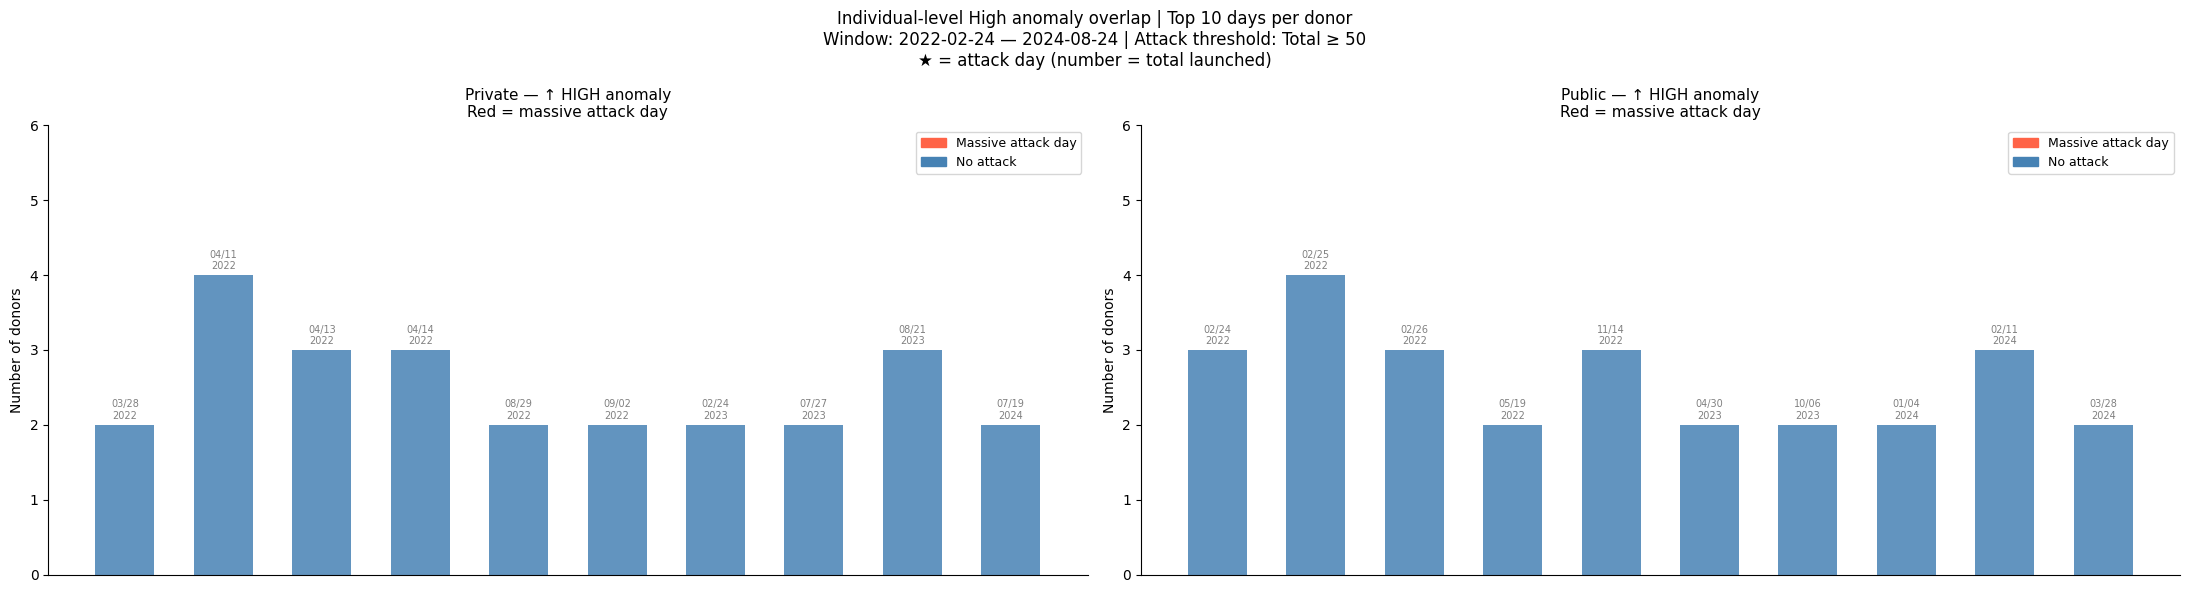

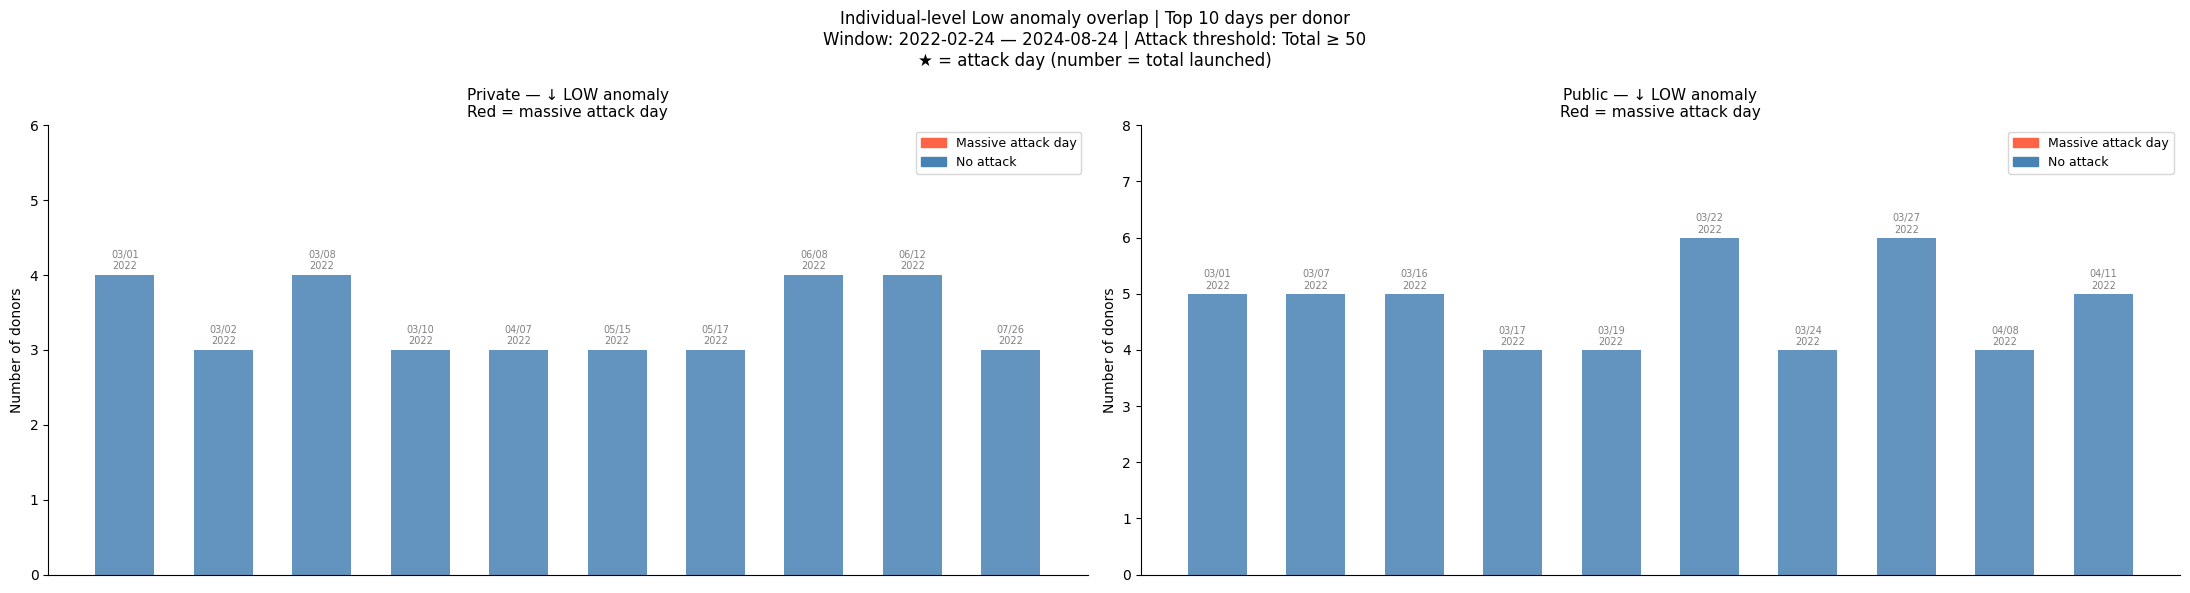

In [11]:
def make_bar_plot(activities, title_prefix, figsize=(22, 6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, (activity, direction) in zip(axes, activities):
        top = summary[(activity, direction)].sort_values("date")
        colors = ["tomato" if is_att else "steelblue" for is_att in top["is_attack"]]
        ax.bar(range(len(top)), top["n_donors"], color=colors, alpha=0.85, width=0.6)
        for j, (_, row) in enumerate(top.iterrows()):
            label = row['date'].strftime('%m/%d\n%Y')
            if row["is_attack"]:
                label += f"\n★{int(row['attack_total'])}"
            ax.text(j, row["n_donors"] + 0.05, label,
                    ha="center", va="bottom", fontsize=7,
                    color="darkred" if row["is_attack"] else "gray")
        ax.set_xticks([])
        ax.set_ylabel("Number of donors", fontsize=10)
        arrow = "↑ HIGH" if direction == "high" else "↓ LOW"
        ax.set_title(f"{activity.capitalize()} — {arrow} anomaly\nRed = massive attack day", fontsize=11)
        ax.set_ylim(0, top["n_donors"].max() + 2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        legend_els = [Patch(color="tomato", label="Massive attack day"),
                      Patch(color="steelblue", label="No attack")]
        ax.legend(handles=legend_els, fontsize=9)
    plt.suptitle(
        f"{title_prefix} | Top {top_n} days per donor\n"
        f"Window: {start.date()} — {end.date()} | Attack threshold: Total ≥ {attack_threshold}\n"
        f"★ = attack day (number = total launched)",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

make_bar_plot(
    [("private", "high"), ("public", "high")],
    "Individual-level High anomaly overlap"
)

make_bar_plot(
    [("private", "low"), ("public", "low")],
    "Individual-level Low anomaly overlap"
)